In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Reading Data

In [2]:
gold_dir = Path("../../data/gold")

# Always load the latest ml_features file
ml_files = sorted(gold_dir.glob("ml_features_load_date=*.parquet"))
if not ml_files:
    raise FileNotFoundError("No ml_features parquet found. Run all_features_to_gold.ipynb first.")

latest = ml_files[-1]
df = pd.read_parquet(latest)
print(f"Loaded: {latest.name}  ->  shape {df.shape}")
print(f"\ndataset_split distribution:")
print(df['dataset_split'].value_counts())

Loaded: ml_features_load_date=2026-03-13.parquet  ->  shape (11999, 79)

dataset_split distribution:
dataset_split
train         9613
validation    1249
test          1137
Name: count, dtype: int64


In [3]:
# Keep 'check' as alias for backwards compatibility with cells below
check = df

## Organizing Columns

In [4]:
check.columns

Index(['_index', 'product_id', 'product_parent', 'label', 'dataset_split',
       'marketplace_id', 'product_category_id', 'vine', 'verified_purchase',
       'review_date', 'detected_language', 'review_age_days',
       'review_relative_rank', 'product_review_count',
       'days_since_first_review', 'is_early_review', 'reviews_same_day',
       'review_month', 'review_dayofweek', 'reviews_per_day',
       'body_word_count', 'headline_word_count', 'type_token_ratio',
       'avg_word_length', 'exclamation_count', 'question_count',
       'sentence_count_approx', 'html_entity_density', 'paragraph_break_count',
       'has_structured_body', 'body_lang_zscore', 'body_cat_zscore',
       'headline_body_ratio', 'exclamation_density', 'question_density',
       'vine_x_marketplace', 'verified_x_category', 'headline_body_cosine_sim',
       'title_body_cosine_sim', 'body_embedding_norm', 'body_sentiment_label',
       'body_sentiment_score', 'body_sentiment_polarity',
       'headline_sentim

In [5]:
print(check.columns.tolist())

['_index', 'product_id', 'product_parent', 'label', 'dataset_split', 'marketplace_id', 'product_category_id', 'vine', 'verified_purchase', 'review_date', 'detected_language', 'review_age_days', 'review_relative_rank', 'product_review_count', 'days_since_first_review', 'is_early_review', 'reviews_same_day', 'review_month', 'review_dayofweek', 'reviews_per_day', 'body_word_count', 'headline_word_count', 'type_token_ratio', 'avg_word_length', 'exclamation_count', 'question_count', 'sentence_count_approx', 'html_entity_density', 'paragraph_break_count', 'has_structured_body', 'body_lang_zscore', 'body_cat_zscore', 'headline_body_ratio', 'exclamation_density', 'question_density', 'vine_x_marketplace', 'verified_x_category', 'headline_body_cosine_sim', 'title_body_cosine_sim', 'body_embedding_norm', 'body_sentiment_label', 'body_sentiment_score', 'body_sentiment_polarity', 'headline_sentiment_label', 'headline_sentiment_score', 'headline_sentiment_polarity', 'sentiment_mismatch', 'repetition

In [6]:
# ── Feature groups ────────────────────────────────────────────────────────────

temporal_features = [
    'review_age_days', 'review_relative_rank', 'product_review_count',
    'days_since_first_review', 'reviews_same_day', 'review_month',
    'review_dayofweek', 'reviews_per_day',
]

language_features = [
    'body_word_count', 'headline_word_count', 'type_token_ratio',
    'avg_word_length', 'exclamation_count', 'question_count',
    'sentence_count_approx', 'html_entity_density', 'paragraph_break_count',
    'body_lang_zscore', 'body_cat_zscore', 'headline_body_ratio',
    'exclamation_density', 'question_density',
]

embedding_features = [
    'headline_body_cosine_sim', 'title_body_cosine_sim', 'body_embedding_norm',
]

sentiment_features = [
    'body_sentiment_score', 'body_sentiment_polarity',
    'headline_sentiment_score', 'headline_sentiment_polarity',
    'sentiment_mismatch', 'repetition_ratio', 'flesch_reading_ease',
    'headline_body_jaccard', 'title_body_jaccard', 'title_body_overlap',
    'body_bigram_diversity', 'uppercase_ratio', 'digit_density',
    'sentence_count', 'avg_sentence_length',
    'flesch_lang_zscore', 'flesch_cat_zscore', 'polarity_lang_zscore',
]

evidence_features = [
    'measurement_count', 'price_ref_count', 'ordinal_comparison_count',
    'measurement_density', 'price_reference_density',
    'ordinal_comparison_density', 'quantitative_evidence_score',
    'evidence_cat_zscore',
]

novelty_features = [
    'product_tfidf_novelty', 'product_vocab_expansion_ratio',
    'product_review_rank_novelty',
]

context_features = [
    'product_popularity_pctile', 'category_review_density',
    'category_product_count', 'days_since_first_x_popularity',
    'popularity_weight',
]

# Boolean features (will be treated as 0/1 integers)
boolean_features = [
    'is_early_review', 'has_structured_body',
    'early_in_popular_product', 'vine_in_sparse_product',
    'verified_in_popular_product',
]

# Categorical features (will be one-hot encoded)
categorical_features = [
    'detected_language', 'vine_x_marketplace', 'verified_x_category',
    'body_sentiment_label', 'headline_sentiment_label',
]

numeric_features = (temporal_features + language_features + embedding_features +
                    sentiment_features + evidence_features + novelty_features +
                    context_features)

all_features = numeric_features + boolean_features + categorical_features

print(f"Total features: {len(all_features)}")
print(f"  Numeric:     {len(numeric_features)}")
print(f"  Boolean:     {len(boolean_features)}")
print(f"  Categorical: {len(categorical_features)}")
print(f"\nAll features present in df: {all(f in check.columns for f in all_features)}")

Total features: 69
  Numeric:     59
  Boolean:     5
  Categorical: 5

All features present in df: True


In [7]:
check_subset = check[all_features + ['label', 'dataset_split']]

In [8]:
# Overview of values per column in check_subset
check_subset.describe(include='all')

,review_age_days,review_relative_rank,product_review_count,days_since_first_review,reviews_same_day,review_month,review_dayofweek,reviews_per_day,body_word_count,headline_word_count,...,early_in_popular_product,vine_in_sparse_product,verified_in_popular_product,detected_language,vine_x_marketplace,verified_x_category,body_sentiment_label,headline_sentiment_label,label,dataset_split
count,11729.000000,11999.000000,11999.000000,11729.000000,11999.000000,11729.000000,11729.000000,8662.000000,11999.000000,11999.000000,...,11999,11997,11999,11999,11999,11999,11999,11087,9613,11999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,27,10,59,3,3,2,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,en,N_0.0,Y_3.0,positive,positive,False,train
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11593,11974,10114,3991,4824,2457,7542,4922,5139,9613
mean,1165.072726,3.241020,5.482040,462.889590,1.014501,6.347941,2.925569,0.024863,84.618218,3.492374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1243.582478,4.912749,8.071029,947.415824,0.131501,3.564608,1.995134,0.100095,146.456988,3.084289,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000361,1.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,366.000000,1.000000,1.000000,0.000000,1.000000,3.000000,1.000000,0.002663,23.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,751.000000,2.000000,3.000000,17.000000,1.000000,6.000000,3.000000,0.006944,38.000000,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1402.000000,3.000000,6.000000,438.000000,1.000000,9.000000,5.000000,0.017433,87.000000,5.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Missing values per column
check_subset.isnull().sum()

review_age_days              270
review_relative_rank           0
product_review_count           0
days_since_first_review      270
reviews_same_day               0
                            ... 
verified_x_category            0
body_sentiment_label           0
headline_sentiment_label     912
label                       2386
dataset_split                  0
Length: 71, dtype: int64

## ML Models

In [10]:
# ── Train/eval split ──────────────────────────────────────────────────────────
# Use only the train split (has labels). The predefined test/validation splits
# are unlabeled, so we hold out 20% of train for evaluation.

train_df = check[check['dataset_split'] == 'train'].copy()

# Convert booleans to int
for col in boolean_features:
    train_df[col] = train_df[col].astype(float)

X = train_df[all_features]
y = train_df['label'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows  |  Val set: {X_val.shape[0]} rows")
print(f"Label balance (train) — True: {y_train.sum()} / False: {(~y_train.astype(bool)).sum()}")

Train set: 7690 rows  |  Val set: 1923 rows
Label balance (train) — True: 3579 / False: 4111


In [11]:
# ── Preprocessing pipeline ────────────────────────────────────────────────────

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

bool_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_transformer,     numeric_features),
    ('bool', bool_transformer,        boolean_features),
    ('cat',  categorical_transformer, categorical_features),
])

# ── Model pipelines ───────────────────────────────────────────────────────────

log_reg_pipeline = Pipeline([
    ('prep',        preprocessor),
    ('classifier',  LogisticRegression(random_state=67, max_iter=1000, C=1.0)),
])

xgb_pipeline = Pipeline([
    ('prep',        preprocessor),
    ('classifier',  XGBClassifier(
        random_state=67,
        eval_metric='logloss',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        verbosity=0,
    )),
])

# ── Train ─────────────────────────────────────────────────────────────────────

print("Training Logistic Regression...")
log_reg_pipeline.fit(X_train, y_train)

print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)

print("Done.")

Training Logistic Regression...
Training XGBoost...
Done.


## Evaluation

In [12]:
def evaluate(name, pipeline, X_val, y_val):
    y_pred  = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    auc     = roc_auc_score(y_val, y_proba)

    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_val, y_pred, target_names=['Genuine', 'Deceptive']))
    print(f"  ROC-AUC: {auc:.4f}")
    print()
    return y_pred, y_proba

lr_pred,  lr_proba  = evaluate("Logistic Regression", log_reg_pipeline, X_val, y_val)
xgb_pred, xgb_proba = evaluate("XGBoost",             xgb_pipeline,     X_val, y_val)

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Genuine       0.74      0.79      0.77      1028
   Deceptive       0.74      0.69      0.71       895

    accuracy                           0.74      1923
   macro avg       0.74      0.74      0.74      1923
weighted avg       0.74      0.74      0.74      1923

  ROC-AUC: 0.8158

──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
              precision    recall  f1-score   support

     Genuine       0.76      0.79      0.77      1028
   Deceptive       0.75      0.71      0.73       895

    accuracy                           0.75      1923
   macro avg       0.75      0.75      0.75      1923
weighted avg       0.75      0.75      0.75      1923

  ROC-AUC: 0.8269



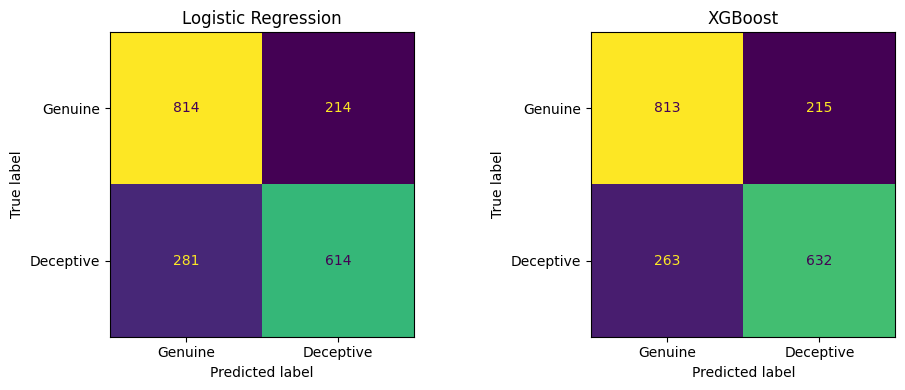

In [13]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in zip(axes,
                               [lr_pred, xgb_pred],
                               ['Logistic Regression', 'XGBoost']):
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Genuine', 'Deceptive']).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Feature Importance

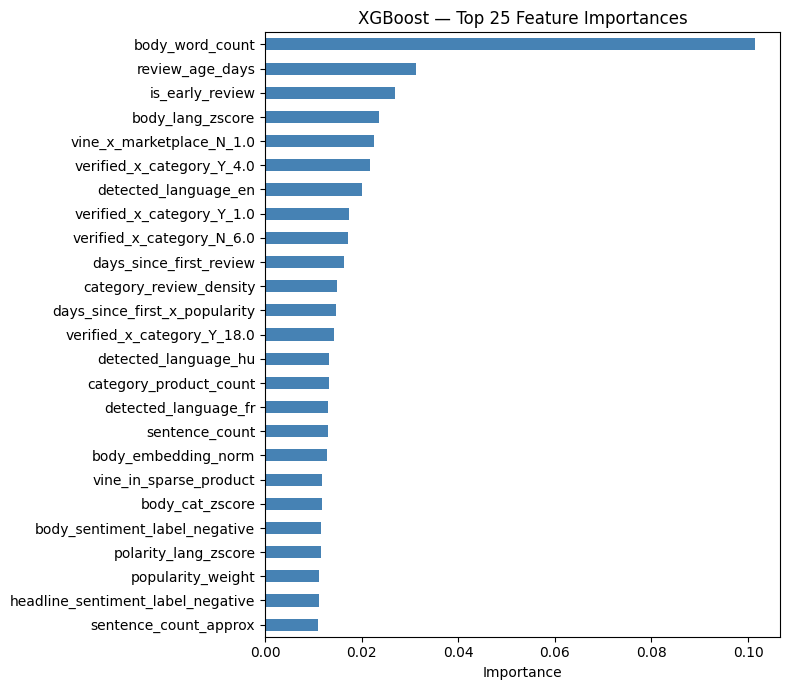


Top 10 features:
body_word_count              0.1015
review_age_days              0.0312
is_early_review              0.0270
body_lang_zscore             0.0236
vine_x_marketplace_N_1.0     0.0227
verified_x_category_Y_4.0    0.0217
detected_language_en         0.0200
verified_x_category_Y_1.0    0.0175
verified_x_category_N_6.0    0.0172
days_since_first_review      0.0164


In [14]:
# ── XGBoost feature importance (top 25) ──────────────────────────────────────

# Recover feature names after ColumnTransformer
cat_feature_names = (xgb_pipeline.named_steps['prep']
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(categorical_features).tolist())

feature_names = numeric_features + boolean_features + cat_feature_names

importances = xgb_pipeline.named_steps['classifier'].feature_importances_
feat_imp = (pd.Series(importances, index=feature_names)
              .sort_values(ascending=False)
              .head(25))

fig, ax = plt.subplots(figsize=(8, 7))
feat_imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Top 25 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10).round(4).to_string())